# 13. Taller posterior

### Parte 1 — Cuadrícula
Construya un mapa de al menos `12 × 12` y ejecute:
- Costo Uniforme;
- A*;
- Beam Search con `k = 1, 2, 4, 8`.

Compare costo de solución, estados expandidos y capacidad para encontrar solución.

In [2]:
from heapq import heappush, heappop
from itertools import count
import random
import math
import matplotlib.pyplot as plt

print("Entorno listo")

Entorno listo


In [4]:
# Creamos el mapa del laberinto
mapa = [[0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1],
        [1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0],
        [0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0],
        [1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1],
        [0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1],
        [0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0],
        [1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1],
        [0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1],
        [1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0],
        [1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0],
        [1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1],
        [0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0]]

# Añadimos el listado de cordenadas claves y movimientos posibles
INICIO=(0,0); OBJETIVO=(11,11)
MOVIMIENTOS=[(1,0),(-1,0),(0,1),(0,-1)]

mapa

[[0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1],
 [1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0],
 [0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0],
 [1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1],
 [0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1],
 [0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0],
 [1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1],
 [0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1],
 [1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0],
 [1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0],
 [1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1],
 [0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0]]

#### Funciones auxiliares del mapa
Generamos los sucesores válidos de una celda (dentro del mapa y sin obstáculo) y la heurística Manhattan

In [ ]:

#Reciclamos codigo del notebook de buqueda informada, se usa elmapa y los MOVIMIENTOS definidos arriba.
def sucesores_mapa(mapa,pos):
    filas=len(mapa); cols=len(mapa[0]); f,c=pos; out=[]
    for df,dc in MOVIMIENTOS:
        nf,nc=f+df,c+dc
        if 0<=nf<filas and 0<=nc<cols and mapa[nf][nc]==0:
            out.append((nf,nc))
    return out

def manhattan(a,b):
    return abs(a[0]-b[0])+abs(a[1]-b[1])

sucesores_mapa((0,0))= [(0, 1)]


#### Búsqueda de Costo Uniforme
Expande siempre el nodo con menor costo acumulado `g(n)`. Es óptima, pero no usa información del objetivo.

In [6]:
# Usaremos la función ucs_mapa del notebook de búsqueda informada.
def ucs_mapa(mapa,inicio,objetivo):
    tie=count(); frontera=[(0,next(tie),inicio,[inicio])]
    mejor_g={inicio:0}; expandidos=0
    while frontera:
        g,_,nodo,camino=heappop(frontera)
        if g != mejor_g.get(nodo): continue
        expandidos += 1
        if nodo==objetivo:
            return {"camino":camino,"costo":g,"expandidos":expandidos}
        for vecino in sucesores_mapa(mapa,nodo):
            ng=g+1
            if ng < mejor_g.get(vecino, math.inf):
                mejor_g[vecino]=ng
                heappush(frontera,(ng,next(tie),vecino,camino+[vecino]))
    return None

resultado_ucs_mapa=ucs_mapa(mapa,INICIO,OBJETIVO)
resultado_ucs_mapa

{'camino': [(0, 0),
  (0, 1),
  (0, 2),
  (0, 3),
  (0, 4),
  (1, 4),
  (2, 4),
  (3, 4),
  (4, 4),
  (4, 5),
  (5, 5),
  (6, 5),
  (6, 6),
  (7, 6),
  (7, 7),
  (7, 8),
  (8, 8),
  (9, 8),
  (9, 9),
  (10, 9),
  (10, 10),
  (11, 10),
  (11, 11)],
 'costo': 22,
 'expandidos': 33}

#### A* con distancia Manhattan
Ordena la frontera por `f(n) = g(n) + h(n)`, con `h` = Manhattan hasta el objetivo.

In [7]:
# Reciclamos nuevamente de"Resolucion_Problemas_Busqueda_Informada" lafunción astar_mapa
def astar_mapa(mapa,inicio,objetivo):
    tie=count(); frontera=[(manhattan(inicio,objetivo),0,next(tie),inicio,[inicio])]
    mejor_g={inicio:0}; expandidos=0
    while frontera:
        f,g,_,nodo,camino=heappop(frontera)
        if g != mejor_g.get(nodo): continue
        expandidos += 1
        if nodo==objetivo:
            return {"camino":camino,"costo":g,"expandidos":expandidos}
        for vecino in sucesores_mapa(mapa,nodo):
            ng=g+1
            if ng < mejor_g.get(vecino, math.inf):
                mejor_g[vecino]=ng
                nf=ng+manhattan(vecino,objetivo)
                heappush(frontera,(nf,ng,next(tie),vecino,camino+[vecino]))
    return None

resultado_astar_mapa=astar_mapa(mapa,INICIO,OBJETIVO)
resultado_astar_mapa

{'camino': [(0, 0),
  (0, 1),
  (0, 2),
  (0, 3),
  (0, 4),
  (1, 4),
  (2, 4),
  (3, 4),
  (4, 4),
  (4, 5),
  (5, 5),
  (6, 5),
  (6, 6),
  (7, 6),
  (7, 7),
  (7, 8),
  (8, 8),
  (9, 8),
  (9, 9),
  (10, 9),
  (10, 10),
  (11, 10),
  (11, 11)],
 'costo': 22,
 'expandidos': 26}

#### Beam Search con `k = 1, 2, 4, 8`
En cada nivel solo conserva los `k` candidatos con menor Manhattan al objetivo. Es rápido y usa poca memoria, pero descarta caminos y puede no encontrar solución.

In [8]:
# Reciclamos de "Resolucion_Problemas_Busqueda_Informada" la función beam_search_mapa
def beam_search_mapa(mapa,inicio,objetivo,beam_width=2):
    haz=[(inicio,[inicio])]
    visitados={inicio}
    expandidos=0

    while haz:
        candidatos=[]
        for nodo,camino in haz:
            expandidos += 1
            if nodo==objetivo:
                return {"camino":camino,"costo":len(camino)-1,"expandidos":expandidos,"beam_width":beam_width}
            for vecino in sucesores_mapa(mapa,nodo):
                if vecino not in visitados:
                    visitados.add(vecino)
                    candidatos.append((vecino,camino+[vecino]))

        candidatos.sort(key=lambda x: manhattan(x[0],objetivo))
        haz=candidatos[:beam_width]
    return None

# validamos la busqueda con los k solicitados por el taller
resultados_beam={}
for k in [1,2,4,8]:
    resultados_beam[k]=beam_search_mapa(mapa,INICIO,OBJETIVO,beam_width=k)
resultados_beam

{1: None,
 2: {'camino': [(0, 0),
   (0, 1),
   (0, 2),
   (0, 3),
   (0, 4),
   (1, 4),
   (2, 4),
   (3, 4),
   (4, 4),
   (4, 5),
   (5, 5),
   (6, 5),
   (6, 6),
   (7, 6),
   (7, 7),
   (7, 8),
   (8, 8),
   (9, 8),
   (9, 9),
   (10, 9),
   (10, 10),
   (11, 10),
   (11, 11)],
  'costo': 22,
  'expandidos': 32,
  'beam_width': 2},
 4: {'camino': [(0, 0),
   (0, 1),
   (0, 2),
   (0, 3),
   (0, 4),
   (1, 4),
   (2, 4),
   (3, 4),
   (4, 4),
   (4, 5),
   (5, 5),
   (6, 5),
   (6, 6),
   (7, 6),
   (7, 7),
   (7, 8),
   (8, 8),
   (9, 8),
   (9, 9),
   (10, 9),
   (10, 10),
   (11, 10),
   (11, 11)],
  'costo': 22,
  'expandidos': 33,
  'beam_width': 4},
 8: {'camino': [(0, 0),
   (0, 1),
   (0, 2),
   (0, 3),
   (0, 4),
   (1, 4),
   (2, 4),
   (3, 4),
   (4, 4),
   (4, 5),
   (5, 5),
   (6, 5),
   (6, 6),
   (7, 6),
   (7, 7),
   (7, 8),
   (8, 8),
   (9, 8),
   (9, 9),
   (10, 9),
   (10, 10),
   (11, 10),
   (11, 11)],
  'costo': 22,
  'expandidos': 33,
  'beam_width': 8}}

#### Visualización de los caminos

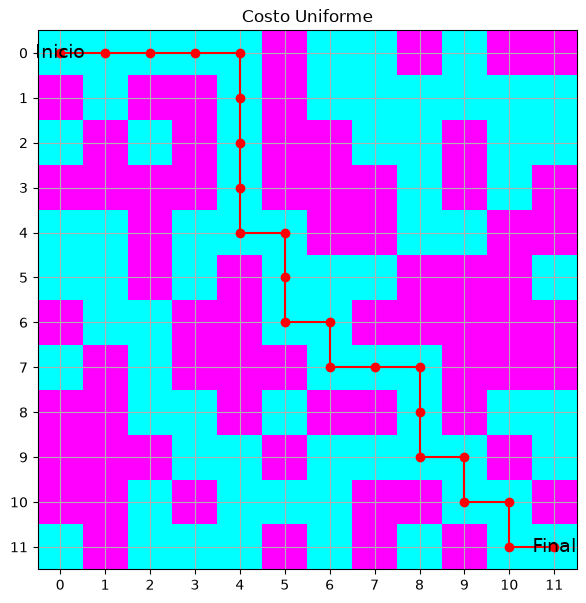

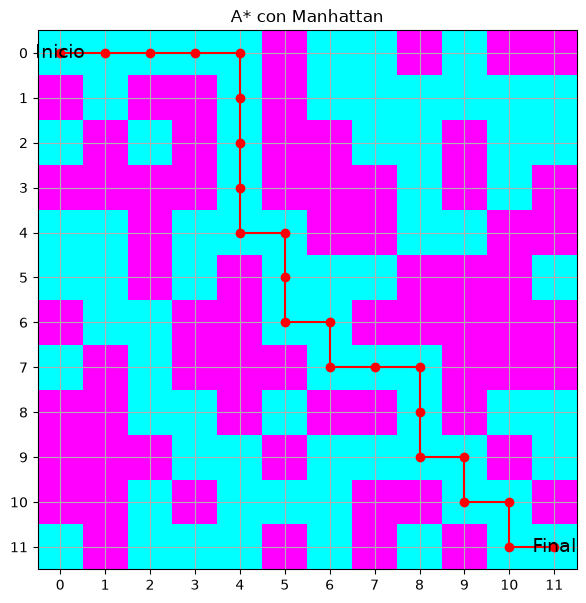

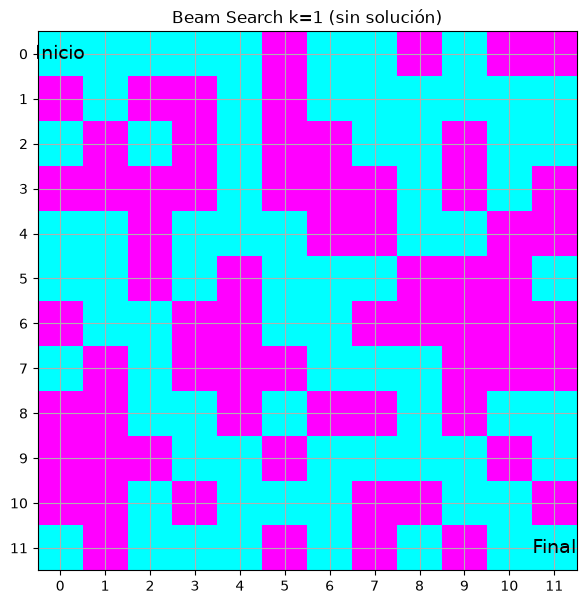

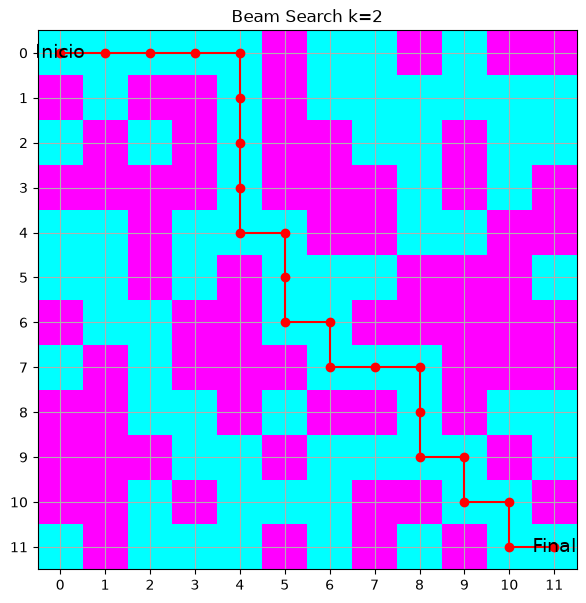

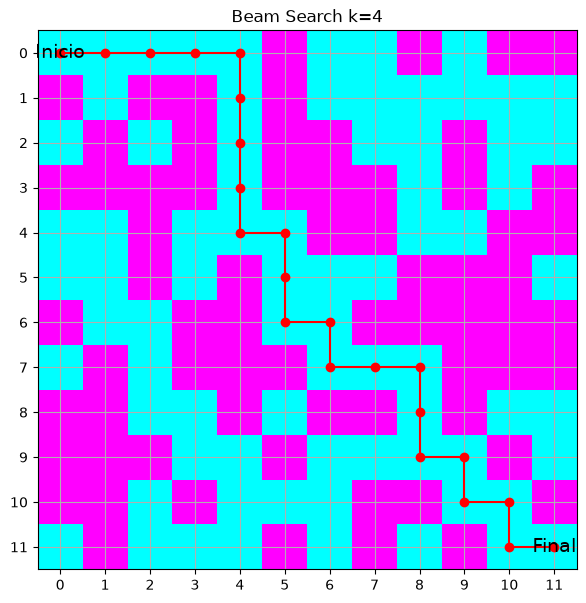

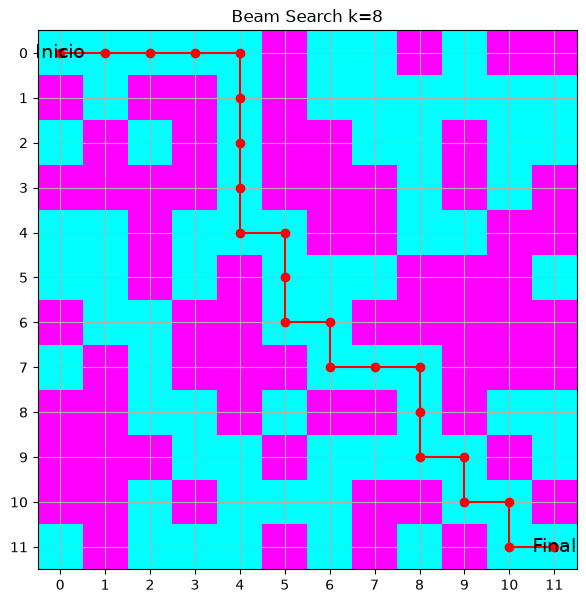

In [11]:
# Validamos de forma visual los resultados de las búsquedas informadas (UCS, A* y Beam Search) sobre el mapa definido
def mostrar_mapa(mapa, camino=None, inicio=None, objetivo=None, titulo="Mapa"):
    fig,ax=plt.subplots(figsize=(7,7))
    ax.imshow(mapa,cmap='cool')
    if camino:
        xs=[c for f,c in camino]; ys=[f for f,c in camino]
        ax.plot(xs,ys,c='red',marker="o")
    if inicio: ax.text(inicio[1],inicio[0],"Inicio",ha="center",va="center",fontsize=14)
    if objetivo: ax.text(objetivo[1],objetivo[0],"Final",ha="center",va="center",fontsize=14)
    ax.set_xticks(range(len(mapa[0]))); ax.set_yticks(range(len(mapa)))
    ax.set_title(titulo); ax.grid(True); plt.show()

#Mapa de resultados para costo uniforme
mostrar_mapa(mapa,resultado_ucs_mapa["camino"],INICIO,OBJETIVO,"Costo Uniforme")

#Mapa de resultados para A*
mostrar_mapa(mapa,resultado_astar_mapa["camino"],INICIO,OBJETIVO,"A* con Manhattan")

#Mapa de resultados para Beam Search
for k,res in resultados_beam.items():
    if res is None:
        mostrar_mapa(mapa,None,INICIO,OBJETIVO,f"Beam Search k={k} (sin solución)")
    else:
        mostrar_mapa(mapa,res["camino"],INICIO,OBJETIVO,f"Beam Search k={k}")

#### Comparación de resultados

In [13]:
# Armamos la tabla de los algoritmos y sus resultados, indicando si encontraron solución, el costo, los nodos expandidos y si es óptimo o no
todos = {"Costo Uniforme": resultado_ucs_mapa, "A*": resultado_astar_mapa}
for k,res in resultados_beam.items():
    todos[f"Beam Search k={k}"] = res

costo_optimo = resultado_ucs_mapa["costo"] if resultado_ucs_mapa else None

print(f"{'Algoritmo':<20}{'¿Solución?':>12}{'Costo':>8}{'Expandidos':>12}{'¿Óptimo?':>10}")
print("-"*62)
for nombre,res in todos.items():
    if res is None:
        print(f"{nombre:<20}{'No':>12}{'-':>8}{'-':>12}{'-':>10}")
    else:
        optimo = "Sí" if res["costo"] == costo_optimo else "No"
        print(f"{nombre:<20}{'Sí':>12}{res['costo']:>8}{res['expandidos']:>12}{optimo:>10}")

Algoritmo             ¿Solución?   Costo  Expandidos  ¿Óptimo?
--------------------------------------------------------------
Costo Uniforme                Sí      22          33        Sí
A*                            Sí      22          26        Sí
Beam Search k=1               No       -           -         -
Beam Search k=2               Sí      22          32        Sí
Beam Search k=4               Sí      22          33        Sí
Beam Search k=8               Sí      22          33        Sí


### Parte 2 — Heurísticas
Implemente dos heurísticas distintas para A* y analice cuál orienta mejor la búsqueda.


### Parte 3 — 8-puzzle
Implemente A* con fichas fuera de lugar y distancia Manhattan y compare con BFS.

### Pregunta final
**¿Puede una búsqueda más rápida producir una solución peor? Explique usando sus experimentos.**

### Uso de IA generativa
Si utiliza IA generativa, indique herramienta, propósito y partes de la actividad en las que fue utilizada. Debe poder explicar y defender completamente el trabajo entregado.
- **Herramienta utilizada**:
- **Propósito de uso**:
- **Partes en las que fue empleada**: